# Week 6 Day 5 - ARIMA Introduction

## Objective

In this notebook we learn the basics of time series forecasting.

Tasks completed:

- Plot Auto Correlation Function (ACF)
- Plot Partial Auto Correlation Function (PACF)
- Calculate log returns
- Fit an ARIMA(1,1,1) model
- Interpret important coefficients

In [13]:
# Import required libraries

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from statsmodels.tsa.arima.model import ARIMA

In [14]:
# Download Reliance historical prices

reliance = yf.download(
    "RELIANCE.NS",
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

reliance.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216187,680.008852,670.390532,675.956671,14004468
2020-01-02,683.660217,686.176147,673.284861,673.284861,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609314,680.365044,667.050769,676.847260,24519177
2020-01-07,678.895691,683.304098,673.952887,676.401995,16683622


In [15]:
# Calculate logarithmic returns

reliance["Log_Return"] = np.log(
    reliance["Close"] /
    reliance["Close"].shift(1)
)

# Remove missing value created by shift()

log_returns = reliance["Log_Return"].dropna()

log_returns.head()

Date
2020-01-02    0.016881
2020-01-03    0.001204
2020-01-06   -0.023465
2020-01-07    0.015268
2020-01-08   -0.007539
Name: Log_Return, dtype: float64

## Auto Correlation Function (ACF)

The ACF shows correlation between current observations and previous observations.

It helps identify the Moving Average (MA) order.

<Figure size 1000x500 with 0 Axes>

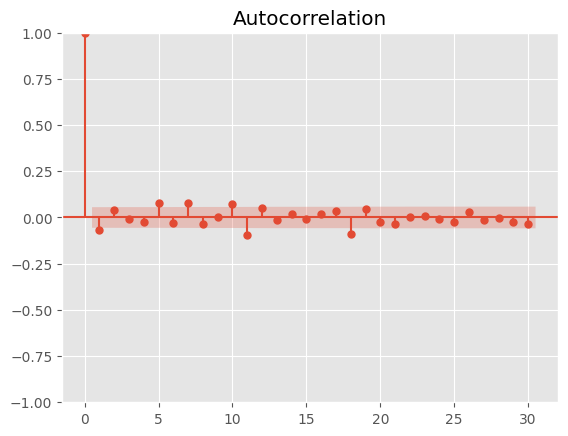

In [16]:
plt.figure(figsize=(10,5))

plot_acf(
    log_returns,
    lags=30
)

plt.savefig(
    "../images/acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Partial Auto Correlation Function (PACF)

PACF removes indirect correlations.

It helps identify the Auto Regression (AR) order.

<Figure size 1000x500 with 0 Axes>

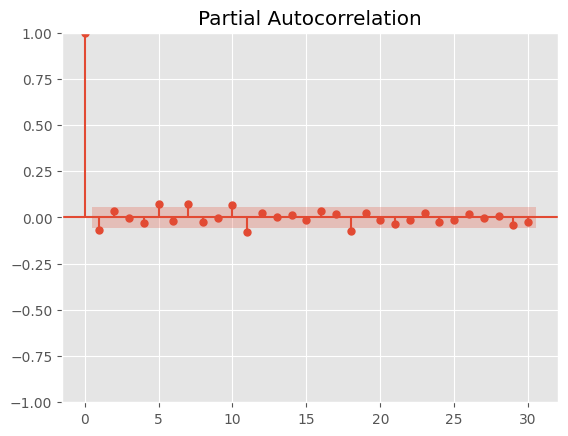

In [17]:
plt.figure(figsize=(10,5))

plot_pacf(
    log_returns,
    lags=30,
    method="ywm"
)

plt.savefig(
    "../images/pacf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ARIMA(1,1,1)

We fit an ARIMA model with

- AR = 1
- Differencing = 1
- MA = 1

This is a simple baseline forecasting model.

In [18]:
# Create ARIMA model

model = ARIMA(
    reliance["Close"],
    order=(1,1,1)
)

# Fit model

model_fit = model.fit()

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

## Interpretation

### AR(1)

The AR coefficient measures how much today's price movement depends on the previous day's movement.

A value close to 1 indicates strong persistence.

---

### MA(1)

The MA coefficient captures the influence of previous forecast errors.

A larger magnitude indicates stronger dependence on recent shocks.

In [19]:
# Print complete model summary

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            RELIANCE.NS   No. Observations:                 1238
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -5305.762
Date:                Sat, 04 Jul 2026   AIC                          10617.525
Time:                        15:54:36   BIC                          10632.886
Sample:                             0   HQIC                         10623.302
                               - 1238                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8139      0.194     -4.204      0.000      -1.193      -0.434
ma.L1          0.7883      0.203      3.887      0.000       0.391       1.186
sigma2       311.2378      7.591     40.999      0.0

In [20]:
# AR coefficient
print("AR(1):", model_fit.params["ar.L1"])

# MA coefficient
print("MA(1):", model_fit.params["ma.L1"])

AR(1): -0.8138869023751157
MA(1): 0.7882819158159383


# Conclusion

• ACF and PACF plots help determine suitable ARIMA orders.

• ARIMA(1,1,1) successfully models the time-series behaviour after differencing.

• The AR coefficient indicates persistence in price movements.

• The MA coefficient reflects the impact of past forecast errors.

• This model provides a simple baseline before exploring more advanced forecasting techniques.